## Что нужно сделать
1. Изучи данные. Что за колонки, какие типы, есть ли проблемы. Документируй как в задаче №1.
2. Посчитай конверсию для каждой группы — сколько процентов пользователей совершили целевое действие.
3. Визуализируй разницу — барчарт конверсий по группам с подписями.
4. Проверь гипотезу — реклама статистически значимо увеличивает конверсию? Используй scipy.stats.
5. Дай рекомендацию директору — вкладывать деньги в рекламу или нет. Обоснуй цифрами.

In [2]:
# Открываем датасет, проводим разведочный анализ
import pandas as pd
df = pd.read_csv('C:/Users/user/OneDrive/Рабочий стол/datasets/Marketing AB test/marketing_AB.csv')
df.head(10)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
5,5,1137664,ad,False,734,Saturday,10
6,6,1116205,ad,False,264,Wednesday,13
7,7,1496843,ad,False,17,Sunday,18
8,8,1448851,ad,False,21,Tuesday,19
9,9,1446284,ad,False,142,Monday,14


In [3]:
df.info(10)
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [28]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [4]:
# Считаем конверсию по группам
dfconvers = df.groupby(df['test group'])['converted'].mean().sort_values(ascending=False)
dfconvers1 = dfconvers * 100
print(dfconvers1.round(2))

test group
ad     2.55
psa    1.79
Name: converted, dtype: float64


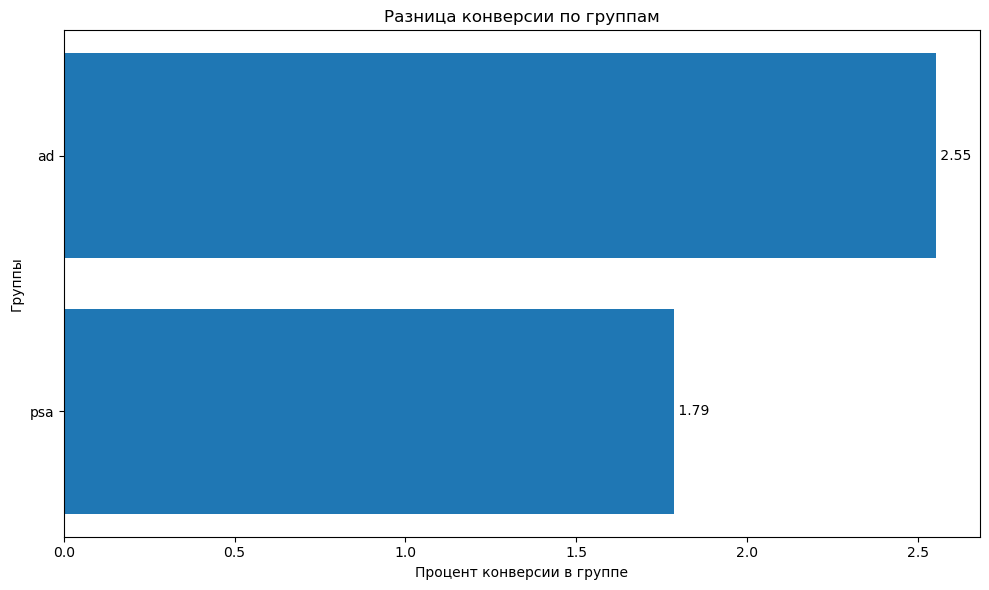

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10, 6))
ax.barh(dfconvers1.index, dfconvers1.values)
ax.set_xlabel('Процент конверсии в группе')
ax.set_ylabel('Группы')
ax.set_title('Разница конверсии по группам')
for i, value in enumerate(dfconvers1.values):
    ax.text(value, i, f' {value:,.2f}', va='center')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Исследуем гипотезу "Влияет ли реклама на продажи?"
Н0 - Показ рекламы никак не влияет на конверсию
Н1 - Показ рекламы увеличил конверсию

In [29]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['test group'], df['converted'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f'chi2: {chi2:.4f}')
print(f'p-value: {p:.2e}')
print(f'Результат: {"Н0 отвергаем" if p < 0.05 else "Н0 не отвергаем"}')

chi2: 54.0058
p-value: 2.00e-13
Результат: Н0 отвергаем


Рекомендация для директора: увеличить рекламный бюджет и повторить эксперимент на более крупной выборке